<a href="https://colab.research.google.com/github/ANKITHATALAPALLY/ML2LAB/blob/main/MLLAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import( accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)


In [5]:


data = """Student_ID,Name,Age,Gender,Study_Hours,Attendance,Assignments,Exam_Score
1,Aarav,19,Male,5.5,92,8,85
2,Diya,20,Female,7.0,95,9,91
3,Rohan,18,Male,3.5,78,6,68
4,Ananya,19,Female,6.0,88,8,82
5,Vikram,21,Male,4.0,75,7,70
6,Meera,20,Female,8.0,98,10,96
7,Arjun,19,Male,,85,7,76
8,Sneha,18,Female,6.5,90,,88
9,Karan,22,Male,2.5,65,5,60
10,Ishita,20,Female,7.5,94,9,93
11,Rahul,21,Male,4.5,,6,72
12,Priya,19,Female,5.0,87,8,80
13,Aditya,20,Male,3.0,72,5,65
14,Nisha,18,Female,6.0,91,8,86
15,Manish,22,Male,4.0,80,7,74
16,Kavya,19,Female,8.5,99,10,98
17,Sameer,21,Male,5.5,89,8,81
18,Pooja,20,Female,7.0,93,9,90
19,Varun,18,Male,3.5,76,6,67
20,Neha,19,Female,6.5,88,8,84"""

with open("student_performance.csv", "w") as file:
    file.write(data)

df = pd.read_csv("student_performance.csv")

print(df.head())
print("Shape:", df.shape)

   Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0           1   Aarav   19    Male          5.5        92.0          8.0   
1           2    Diya   20  Female          7.0        95.0          9.0   
2           3   Rohan   18    Male          3.5        78.0          6.0   
3           4  Ananya   19  Female          6.0        88.0          8.0   
4           5  Vikram   21    Male          4.0        75.0          7.0   

   Exam_Score  
0          85  
1          91  
2          68  
3          82  
4          70  
Shape: (20, 8)


In [6]:
import matplotlib.pyplot as plt

In [7]:
print(df)

    Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0            1   Aarav   19    Male          5.5        92.0          8.0   
1            2    Diya   20  Female          7.0        95.0          9.0   
2            3   Rohan   18    Male          3.5        78.0          6.0   
3            4  Ananya   19  Female          6.0        88.0          8.0   
4            5  Vikram   21    Male          4.0        75.0          7.0   
5            6   Meera   20  Female          8.0        98.0         10.0   
6            7   Arjun   19    Male          NaN        85.0          7.0   
7            8   Sneha   18  Female          6.5        90.0          NaN   
8            9   Karan   22    Male          2.5        65.0          5.0   
9           10  Ishita   20  Female          7.5        94.0          9.0   
10          11   Rahul   21    Male          4.5         NaN          6.0   
11          12   Priya   19  Female          5.0        87.0          8.0   

In [8]:
print(df.head())

   Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0           1   Aarav   19    Male          5.5        92.0          8.0   
1           2    Diya   20  Female          7.0        95.0          9.0   
2           3   Rohan   18    Male          3.5        78.0          6.0   
3           4  Ananya   19  Female          6.0        88.0          8.0   
4           5  Vikram   21    Male          4.0        75.0          7.0   

   Exam_Score  
0          85  
1          91  
2          68  
3          82  
4          70  


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   20 non-null     int64  
 1   Name         20 non-null     object 
 2   Age          20 non-null     int64  
 3   Gender       20 non-null     object 
 4   Study_Hours  19 non-null     float64
 5   Attendance   19 non-null     float64
 6   Assignments  19 non-null     float64
 7   Exam_Score   20 non-null     int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 1.4+ KB
None


In [10]:
print(df.isnull().sum())

Student_ID     0
Name           0
Age            0
Gender         0
Study_Hours    1
Attendance     1
Assignments    1
Exam_Score     0
dtype: int64


### Handling Missing Values

From the `df.isnull().sum()` output, we can see that 'Study_Hours', 'Attendance', and 'Assignments' columns have one missing value each. For numerical columns, a common strategy is to impute these missing values with the mean of their respective columns. This helps maintain the overall distribution of the data without introducing bias.

In [38]:

df['Study_Hours'].fillna(df['Study_Hours'].mean(), inplace=True)
df['Attendance'].fillna(df['Attendance'].mean(), inplace=True)
df['Assignments'].fillna(df['Assignments'].mean(), inplace=True)
print(df.isnull().sum())

Student_ID     0
Name           0
Age            0
Gender         0
Study_Hours    0
Attendance     0
Assignments    0
Exam_Score     0
Result         0
dtype: int64


/tmp/ipykernel_1501/2735260980.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Study_Hours'].fillna(df['Study_Hours'].mean(), inplace=True)
/tmp/ipykernel_1501/2735260980.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [12]:
print(df)

    Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0            1   Aarav   19    Male     5.500000   92.000000     8.000000   
1            2    Diya   20  Female     7.000000   95.000000     9.000000   
2            3   Rohan   18    Male     3.500000   78.000000     6.000000   
3            4  Ananya   19  Female     6.000000   88.000000     8.000000   
4            5  Vikram   21    Male     4.000000   75.000000     7.000000   
5            6   Meera   20  Female     8.000000   98.000000    10.000000   
6            7   Arjun   19    Male     5.473684   85.000000     7.000000   
7            8   Sneha   18  Female     6.500000   90.000000     7.578947   
8            9   Karan   22    Male     2.500000   65.000000     5.000000   
9           10  Ishita   20  Female     7.500000   94.000000     9.000000   
10          11   Rahul   21    Male     4.500000   86.052632     6.000000   
11          12   Priya   19  Female     5.000000   87.000000     8.000000   

In [20]:
X = df[['Age', 'Gender', 'Study_Hours', 'Attendance', 'Assignments']]
y = df['Result']

In [27]:
print(df)

    Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0            1   Aarav   19    Male     5.500000   92.000000     8.000000   
1            2    Diya   20  Female     7.000000   95.000000     9.000000   
2            3   Rohan   18    Male     3.500000   78.000000     6.000000   
3            4  Ananya   19  Female     6.000000   88.000000     8.000000   
4            5  Vikram   21    Male     4.000000   75.000000     7.000000   
5            6   Meera   20  Female     8.000000   98.000000    10.000000   
6            7   Arjun   19    Male     5.473684   85.000000     7.000000   
7            8   Sneha   18  Female     6.500000   90.000000     7.578947   
8            9   Karan   22    Male     2.500000   65.000000     5.000000   
9           10  Ishita   20  Female     7.500000   94.000000     9.000000   
10          11   Rahul   21    Male     4.500000   86.052632     6.000000   
11          12   Priya   19  Female     5.000000   87.000000     8.000000   

In [28]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(y_encoded)
y = y_encoded

[1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1]


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
print("training sample:",len(X_train))

training sample: 16


In [31]:
print("testing samples:",len(X_test))

testing samples: 4


In [32]:
model=DecisionTreeClassifier(random_state=42)

In [34]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
y_pred=model.predict(X_test)

In [36]:
print("actual",y_test)

actual [1 0 1 1]


In [37]:
print("predicted",y_pred)

predicted [1 0 1 1]


In [39]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 1.0


In [41]:
precision=precision_score(y_test,y_pred,zero_division=0)
print("precision:",precision)

precision: 1.0


In [42]:
recall=recall_score(y_test,y_pred)
print("recall:",recall)

recall: 1.0


In [43]:
f1=f1_score(y_test,y_pred,zero_division=0)
print("f1 score:",f1)

f1 score: 1.0


In [44]:
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)

confusion matrix:
 [[1 0]
 [0 3]]


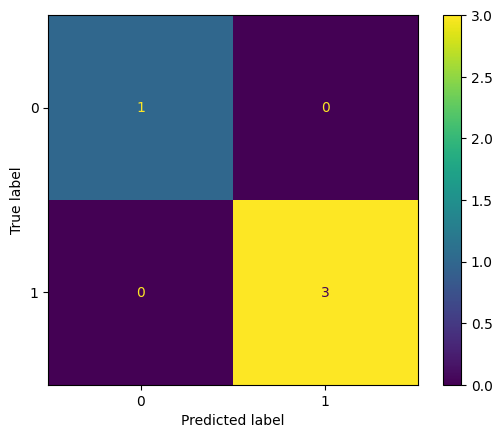

In [45]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
disp.plot()
plt.show()